In [1]:
# Cell 1 — Setup: imports, paths, load feature matrix, split, feature list
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator  # sklearn 1.6+: replaces cv='prefit'
from sklearn.metrics import (
    brier_score_loss, average_precision_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

from models.utils import (
    chronological_split,
    select_enhanced_features,
    TARGET_REG,
    TARGET_CLASS,
    regression_report,
    classification_report,
    apply_feature_transforms,

)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

FEATURES    = PROJECT_ROOT / "data" / "features"
ARTIFACTS   = PROJECT_ROOT / "models" / "artifacts"

mat = pd.read_parquet(FEATURES / "feature_matrix_engineered_v2.parquet")
mat = apply_feature_transforms(mat)

train, val, test = chronological_split(mat)

features = select_enhanced_features(mat)
print(f"\n{len(features)} features selected")
print("First 10:", features[:10], "...")
print("Last 10: ", features[-10:])

  Split boundaries:
    Train: 2016-01-31 06:00:00+00:00 → 2022-12-31 23:00:00+00:00 (60,429 rows)
    Val:   2023-01-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00 (8,760 rows)
    Test:  2024-01-01 00:00:00+00:00 → 2024-12-31 06:00:00+00:00 (8,767 rows)

87 features selected
First 10: ['Houston_cloud_cover', 'Houston_precipitation', 'Houston_relative_humidity_2m', 'Houston_temperature_2m', 'Houston_wind_gusts_10m', 'Houston_wind_speed_10m', 'North (Dallas)_cloud_cover', 'North (Dallas)_precipitation', 'North (Dallas)_relative_humidity_2m', 'North (Dallas)_temperature_2m'] ...
Last 10:  ['stress_gas_spike', 'stress_heat_wave', 'stress_low_wind', 'stress_reactor_outage', 'stress_score', 'temp_max_across_zones', 'temp_min_across_zones', 'temp_range_across_zones', 'wind_mean_across_zones', 'wind_min_across_zones']


In [2]:
mat

,HB_HOUSTON,HB_NORTH,HB_SOUTH,HB_WEST,HB_HUBAVG,price_spike_flag,da_HB_HOUSTON,da_HB_NORTH,da_HB_SOUTH,da_HB_WEST,da_HB_HUBAVG,Houston_temperature_2m,Houston_relative_humidity_2m,Houston_cloud_cover,Houston_wind_speed_10m,Houston_wind_gusts_10m,Houston_precipitation,North (Dallas)_temperature_2m,North (Dallas)_relative_humidity_2m,North (Dallas)_cloud_cover,North (Dallas)_wind_speed_10m,North (Dallas)_wind_gusts_10m,North (Dallas)_precipitation,South (San Antonio)_temperature_2m,South (San Antonio)_relative_humidity_2m,South (San Antonio)_cloud_cover,South (San Antonio)_wind_speed_10m,South (San Antonio)_wind_gusts_10m,South (San Antonio)_precipitation,West (Midland)_temperature_2m,West (Midland)_relative_humidity_2m,West (Midland)_cloud_cover,West (Midland)_wind_speed_10m,West (Midland)_wind_gusts_10m,West (Midland)_precipitation,load_actual_mw,gdelt_tone,gdelt_norm,gdelt_article_volume,gdelt_tone_lag_1d,gdelt_tone_lag_2d,gdelt_tone_lag_3d,gdelt_volume_lag_1d,gdelt_volume_lag_2d,gdelt_tone_change_1d,gdelt_tone_change_3d,gdelt_volume_change_1d,gdelt_volume_change_3d,gdelt_volume_zscore_30d,gdelt_tone_zscore_30d,henry_hub_price,henry_hub_lag_1d,henry_hub_change_1d,henry_hub_change_7d,reactor_comanche_peak_1_pct,reactor_comanche_peak_2_pct,reactor_south_texas_1_pct,reactor_south_texas_2_pct,reactors_offline_pct_sum,reactors_offline_change_1d,storage_bcf,storage_wow_change,storage_bcf_lag_1w,hubavg_lag_1h,hubavg_lag_12h,hubavg_lag_24h,hubavg_lag_48h,hubavg_lag_168h,hubavg_lag_720h,hubavg_rollmean_24h,hubavg_rollstd_24h,hubavg_rollmean_168h,hubavg_rollstd_168h,load_lag_1h,load_rollmean_24h,temp_min_across_zones,temp_max_across_zones,temp_range_across_zones,wind_mean_across_zones,wind_min_across_zones,stress_cold_snap,stress_freeze,stress_heat_wave,stress_extreme_heat,stress_low_wind,stress_gas_spike,stress_reactor_outage,stress_score,hour,day_of_week,month,is_weekend,is_peak_hours,future_spike_24h,future_price_max_24h
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-31 06:00:00+00:00,-1.04,-1.05,-1.03,-0.94,-1.02,False,1.981001,1.976855,1.955860,1.780024,1.927164,62.4,83,86,2.617396,3.113515,0.0,59.6,72,0,3.010621,3.529297,0.0,57.7,90,46,2.272126,2.815409,0.0,58.0,23,0,2.674149,3.206803,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.187843,1.187843,0.00000,0.067659,100.0,100.0,100.0,100.0,0.0,-86.0,7.984463,0.0,8.034955,0.000000,2.827314,2.939691,2.650421,2.452728,2.803360,2.712595,1.874052,3.096097,3.530824,NaN,NaN,57.7,62.4,4.7,13.550,8.7,0,0,0,0,0,0,0,0,6,6,1,1,0,0,31.42
2016-01-31 07:00:00+00:00,-15.93,-15.93,-15.93,-15.93,-15.93,False,1.897620,1.884035,1.874874,1.764731,1.856298,63.3,84,89,2.580217,3.139833,0.0,59.1,77,0,2.975530,3.502550,0.0,57.1,92,0,2.174752,2.815409,0.0,57.0,24,0,2.660260,3.122365,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.187843,1.187843,0.00000,0.067659,100.0,100.0,100.0,100.0,0.0,-86.0,7.984463,0.0,8.034955,0.000000,2.723924,2.899221,2.618125,2.444952,2.795450,2.658831,1.980517,3.092959,3.531825,NaN,NaN,57.0,63.3,6.3,12.975,7.8,0,0,0,0,0,0,0,0,7,6,1,1,0,0,31.42
2016-01-31 08:00:00+00:00,-10.91,-10.91,-10.91,-10.90,-10.91,False,1.891605,1.877937,1.870263,1.769855,1.853168,63.0,84,93,2.549445,3.113515,0.0,58.4,82,0,2.960105,3.475067,0.0,56.0,95,0,2.041220,2.667228,0.0,56.8,25,0,2.740840,3.169686,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.187843,1.187843,0.00000,0.067659,100.0,100.0,100.0,100.0,0.0,-86.0,7.984463,0.0,8.034955,0.000000,2.637628,2.889816,2.612273,2.474856,2.779440,2.557292,2.258823,3.085788,3.535119,NaN,NaN,56.0,63.0,7.0,12.825,6.7,0,0,0,0,0,0,0,0,8,6,1,1,0,0,31.42
2016-01-31 09:00:00+00:00,-1.32,-1.32,-1.32,-1.32,-1.32,False,1.843719,1.829376,1.830980,1.781709,1.821318,62.4,86,97,2.541602,3.072693,0.0,57.9,85,0,2.928524,3.453157,0.0,54.9,96,4,2.001480,2.517696,0.0,57.8,24,0,2.867899,3.303217,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.187843,

In [3]:
# Cell 2 — Feature-list sanity
print(f"Total enhanced features: {len(features)}")
print("  (expected ~87 after the weather-suffix fix in models/utils.py)\n")

trend_in_features = [f for f in features if "trend_" in f]
print(f"trend_* in feature list (expect []): {trend_in_features}")

print(f"'gdelt_norm' present:       {'gdelt_norm' in features}")
print(f"'hubavg_lag_720h' present:  {'hubavg_lag_720h' in features}")

gdelt_feats = [f for f in features if f.startswith("gdelt_")]
print(f"\nAll gdelt_* features in list: {gdelt_feats}")

lag_feats = sorted(f for f in features if f.startswith("hubavg_lag_"))
print(f"All hubavg_lag_* features:   {lag_feats}")

Total enhanced features: 87
  (expected ~87 after the weather-suffix fix in models/utils.py)

trend_* in feature list (expect []): []
'gdelt_norm' present:       True
'hubavg_lag_720h' present:  True

All gdelt_* features in list: ['gdelt_article_volume', 'gdelt_norm', 'gdelt_tone', 'gdelt_tone_change_1d', 'gdelt_tone_change_3d', 'gdelt_tone_lag_1d', 'gdelt_tone_lag_2d', 'gdelt_tone_lag_3d', 'gdelt_tone_zscore_30d', 'gdelt_volume_change_1d', 'gdelt_volume_change_3d', 'gdelt_volume_lag_1d', 'gdelt_volume_lag_2d', 'gdelt_volume_zscore_30d']
All hubavg_lag_* features:   ['hubavg_lag_12h', 'hubavg_lag_168h', 'hubavg_lag_1h', 'hubavg_lag_24h', 'hubavg_lag_48h', 'hubavg_lag_720h']


In [4]:
# Cell 3 — Model 1: Enhanced Regressor (HB_HUBAVG)
# Hyperparameters copied verbatim from models/train_all_v2.py _train_regressor()

# Prepare regression splits (drop NaN targets)
df_reg = mat.dropna(subset=[TARGET_REG])
tr_reg, vl_reg, te_reg = chronological_split(df_reg)

X_train_r = tr_reg[features].ffill().fillna(0);  y_train_r = tr_reg[TARGET_REG]
X_val_r   = vl_reg[features].ffill().fillna(0);  y_val_r   = vl_reg[TARGET_REG]
X_test_r  = te_reg[features].ffill().fillna(0);  y_test_r  = te_reg[TARGET_REG]

reg = xgb.XGBRegressor(      # same model as baseline, but with sentiment features
        n_estimators=700,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        tree_method="hist",
        early_stopping_rounds=30,
        eval_metric="rmse",
        n_jobs=-1,
        random_state=42,
    )
reg.fit(X_train_r, y_train_r, eval_set=[(X_val_r, y_val_r)], verbose=False)

y_pred_test_r = reg.predict(X_test_r)
print("\nTest-set metrics:")
regression_report(y_test_r.values, y_pred_test_r, name="enhanced_v2_regressor (interactive)")

  Split boundaries:
    Train: 2016-01-31 06:00:00+00:00 → 2022-12-31 23:00:00+00:00 (60,428 rows)
    Val:   2023-01-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00 (8,760 rows)
    Test:  2024-01-01 00:00:00+00:00 → 2024-12-31 06:00:00+00:00 (8,767 rows)



Test-set metrics:

--- Regression report: enhanced_v2_regressor (interactive) ---
  MAE:             $22.21/MWh
  RMSE:            $108.88/MWh
  Spike recall:    54.39%
  Spike precision: 30.24%
---------------------------------



{'name': 'enhanced_v2_regressor (interactive)',
 'mae': 22.205501156786333,
 'rmse': np.float64(108.88302242764767),
 'spike_recall': np.float64(0.543859649122807),
 'spike_precision': np.float64(0.3024390243902439)}

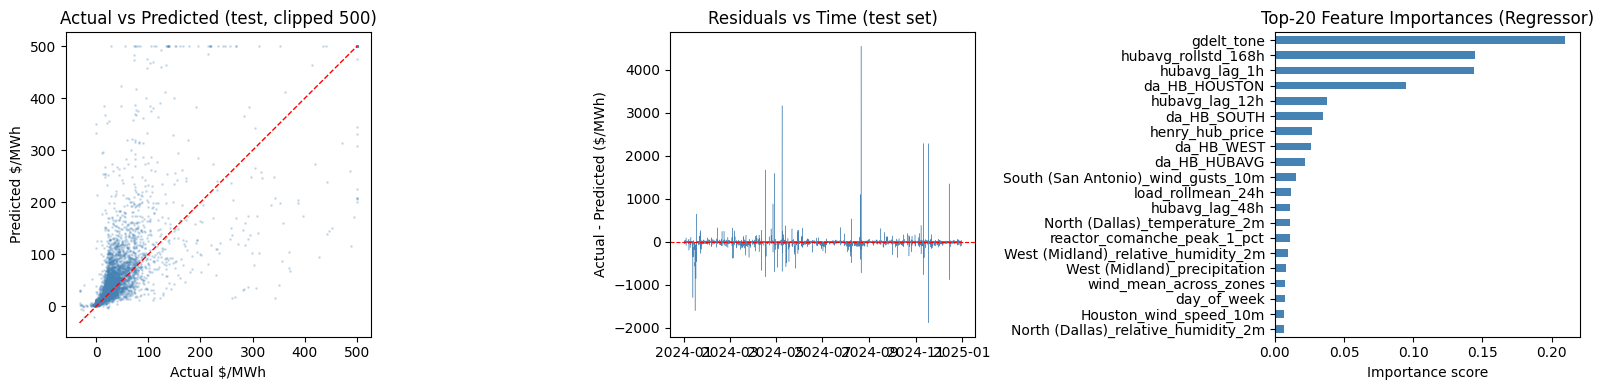

In [5]:
# Cell 3 (continued) — Regressor plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Actual vs predicted scatter
clip_hi = 500
ax = axes[0]
ax.scatter(
    y_test_r.clip(-50, clip_hi),
    np.clip(y_pred_test_r, -50, clip_hi),
    s=1, alpha=0.2, color="steelblue"
)
lo, hi = y_test_r.clip(-50, clip_hi).min(), y_test_r.clip(-50, clip_hi).max()
ax.plot([lo, hi], [lo, hi], "r--", lw=1)
ax.set_title("Actual vs Predicted (test, clipped 500)")
ax.set_xlabel("Actual $/MWh")
ax.set_ylabel("Predicted $/MWh")

# 2. Residuals vs time
residuals = y_test_r.values - y_pred_test_r
axes[1].plot(te_reg.index, residuals, lw=0.3, color="steelblue")
axes[1].axhline(0, color="red", lw=0.8, linestyle="--")
axes[1].set_title("Residuals vs Time (test set)")
axes[1].set_ylabel("Actual - Predicted ($/MWh)")

# 3. Feature importance (top 20)
imp_series = pd.Series(reg.feature_importances_, index=features).sort_values(ascending=False)
imp_series.head(20).sort_values().plot.barh(ax=axes[2], color="steelblue")
axes[2].set_title("Top-20 Feature Importances (Regressor)")
axes[2].set_xlabel("Importance score")

plt.tight_layout()
plt.show()

  Split boundaries:
    Train: 2016-01-31 06:00:00+00:00 → 2022-12-31 23:00:00+00:00 (60,429 rows)
    Val:   2023-01-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00 (8,760 rows)
    Test:  2024-01-01 00:00:00+00:00 → 2024-12-31 06:00:00+00:00 (8,767 rows)
  Positive class weight: 3.08



Validation metrics:

--- Classification report: enhanced_v2_clf val ---
  PR-AUC:    0.542
  ROC-AUC:   0.693
  Recall:    64.73%  (at threshold 0.5)
  Precision: 40.95%
  Confusion: TP=1657  FP=2389  FN=903  TN=3811
-------------------------------------


Test metrics:

--- Classification report: enhanced_v2_clf test ---
  PR-AUC:    0.255
  ROC-AUC:   0.609
  Recall:    48.44%  (at threshold 0.5)
  Precision: 23.77%
  Confusion: TP=712  FP=2284  FN=758  TN=5013
-------------------------------------



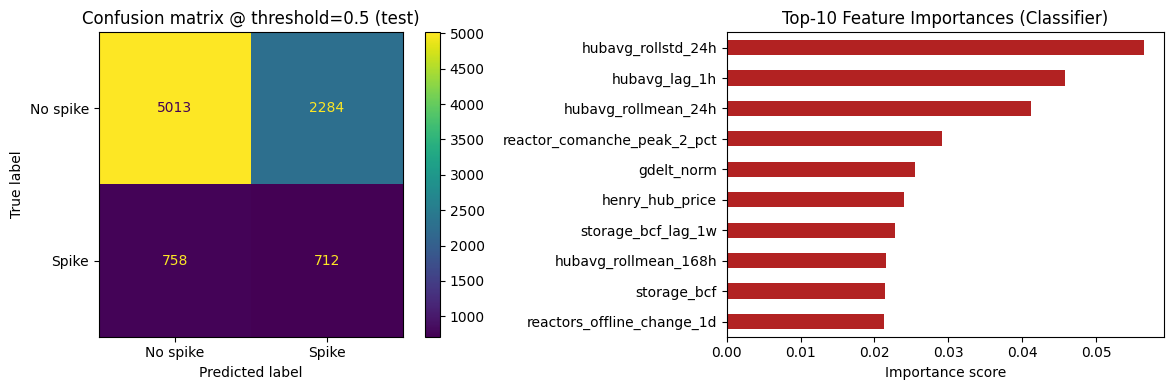


Probability distribution on test set:
  min=0.322  Q1=0.427  median=0.473  Q3=0.516  max=0.716


In [6]:
# Cell 4 — Model 2: Enhanced Classifier (future_spike_24h)
# Hyperparameters copied verbatim from models/train_all_v2.py _train_classifier()

# Prepare classification splits (drop NaN targets)
df_clf = mat.dropna(subset=[TARGET_CLASS])
tr_clf, vl_clf, te_clf = chronological_split(df_clf)

X_train_c = tr_clf[features].ffill().fillna(0);  y_train_c = tr_clf[TARGET_CLASS]
X_val_c   = vl_clf[features].ffill().fillna(0);  y_val_c   = vl_clf[TARGET_CLASS]
X_test_c  = te_clf[features].ffill().fillna(0);  y_test_c  = te_clf[TARGET_CLASS]

pos_weight = (y_train_c == 0).sum() / max((y_train_c == 1).sum(), 1)
print(f"  Positive class weight: {pos_weight:.2f}")

clf = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=pos_weight,
    tree_method="hist",
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=42,
)
clf.fit(X_train_c, y_train_c, eval_set=[(X_val_c, y_val_c)], verbose=False)

val_proba  = clf.predict_proba(X_val_c)[:, 1]
test_proba = clf.predict_proba(X_test_c)[:, 1]

print("\nValidation metrics:")
classification_report(y_val_c.values, val_proba, name="enhanced_v2_clf val")
print("\nTest metrics:")
classification_report(y_test_c.values, test_proba, name="enhanced_v2_clf test")

# Confusion matrix at 0.5
cm = confusion_matrix(y_test_c, (test_proba >= 0.5).astype(int), labels=[0, 1])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(cm, display_labels=["No spike", "Spike"]).plot(ax=axes[0])
axes[0].set_title("Confusion matrix @ threshold=0.5 (test)")

# Top-10 features by importance
clf_imp = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
clf_imp.head(10).sort_values().plot.barh(ax=axes[1], color="firebrick")
axes[1].set_title("Top-10 Feature Importances (Classifier)")
axes[1].set_xlabel("Importance score")
plt.tight_layout()
plt.show()

print("\nProbability distribution on test set:")
qs = np.quantile(test_proba, [0, 0.25, 0.5, 0.75, 1.0])
print(f"  min={qs[0]:.3f}  Q1={qs[1]:.3f}  median={qs[2]:.3f}  Q3={qs[3]:.3f}  max={qs[4]:.3f}")

Brier scores on test set (lower = better calibrated):
  uncalibrated:  0.2305
  platt:         0.1452
  isotonic:      0.1459
  ==> Best calibrator (lowest Brier): platt
  (calibrate_classifier.py picks by the same rule; isotonic expected)


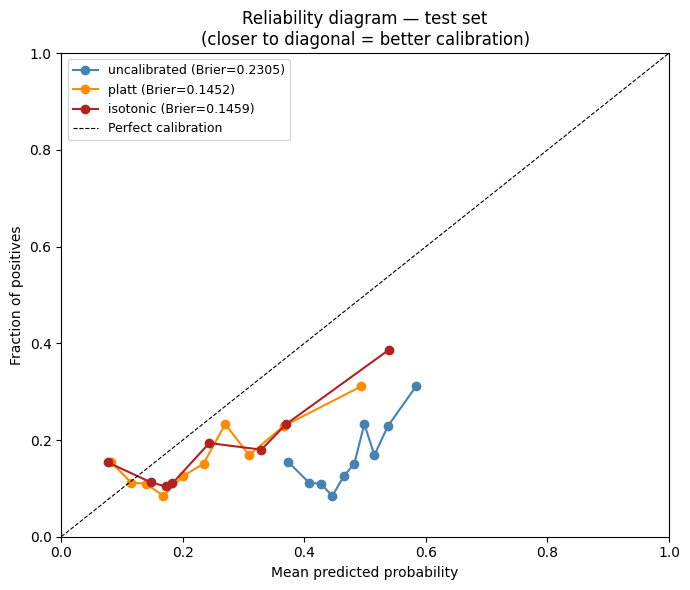

In [7]:
# Cell 5 — Model 3: Calibrated Wrapper
# Reproduces models/calibrate_classifier.py: FrozenEstimator (sklearn>=1.6) replaces cv='prefit',
# both methods, best selected by lowest Brier score.

# Platt scaling (sigmoid)
cal_platt = CalibratedClassifierCV(FrozenEstimator(clf), method="sigmoid")
cal_platt.fit(X_val_c, y_val_c)

# Isotonic regression
cal_isotonic = CalibratedClassifierCV(FrozenEstimator(clf), method="isotonic")
cal_isotonic.fit(X_val_c, y_val_c)

proba_raw      = test_proba
proba_platt    = cal_platt.predict_proba(X_test_c)[:, 1]
proba_isotonic = cal_isotonic.predict_proba(X_test_c)[:, 1]

print("Brier scores on test set (lower = better calibrated):")
b_raw      = brier_score_loss(y_test_c, proba_raw)
b_platt    = brier_score_loss(y_test_c, proba_platt)
b_isotonic = brier_score_loss(y_test_c, proba_isotonic)
print(f"  uncalibrated:  {b_raw:.4f}")
print(f"  platt:         {b_platt:.4f}")
print(f"  isotonic:      {b_isotonic:.4f}")

best_label = "isotonic" if b_isotonic < b_platt else "platt"
print(f"  ==> Best calibrator (lowest Brier): {best_label}")
print("  (calibrate_classifier.py picks by the same rule; isotonic expected)")

# Reliability diagram
fig, ax = plt.subplots(figsize=(7, 6))
for label, proba, color in [
    ("uncalibrated", proba_raw, "steelblue"),
    ("platt", proba_platt, "darkorange"),
    ("isotonic", proba_isotonic, "firebrick"),
]:
    frac_pos, mean_pred = calibration_curve(
        y_test_c, proba, n_bins=10, strategy="quantile"
    )
    ax.plot(mean_pred, frac_pos, marker="o", lw=1.5, label=f"{label} (Brier={brier_score_loss(y_test_c, proba):.4f})", color=color)

ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Perfect calibration")
ax.set_title("Reliability diagram — test set\n(closer to diagonal = better calibration)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

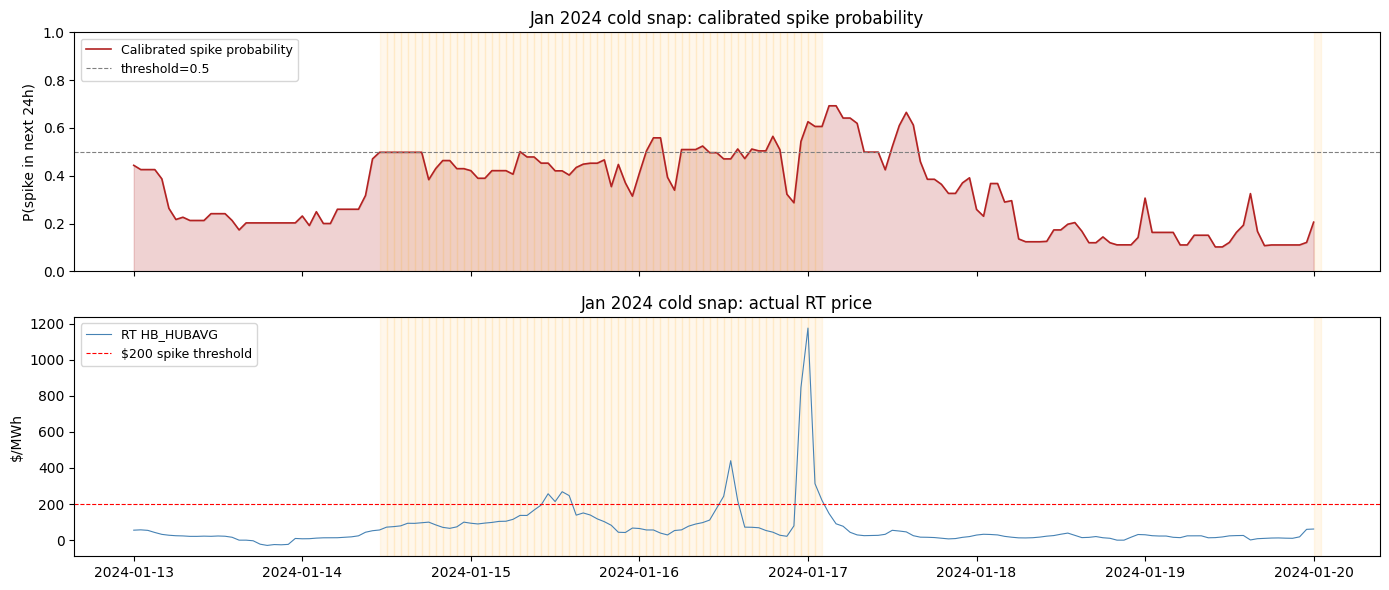

  Jan 2024 cold snap: 169 hours,  spike hours flagged: 64
  Prob range: [0.102, 0.693]


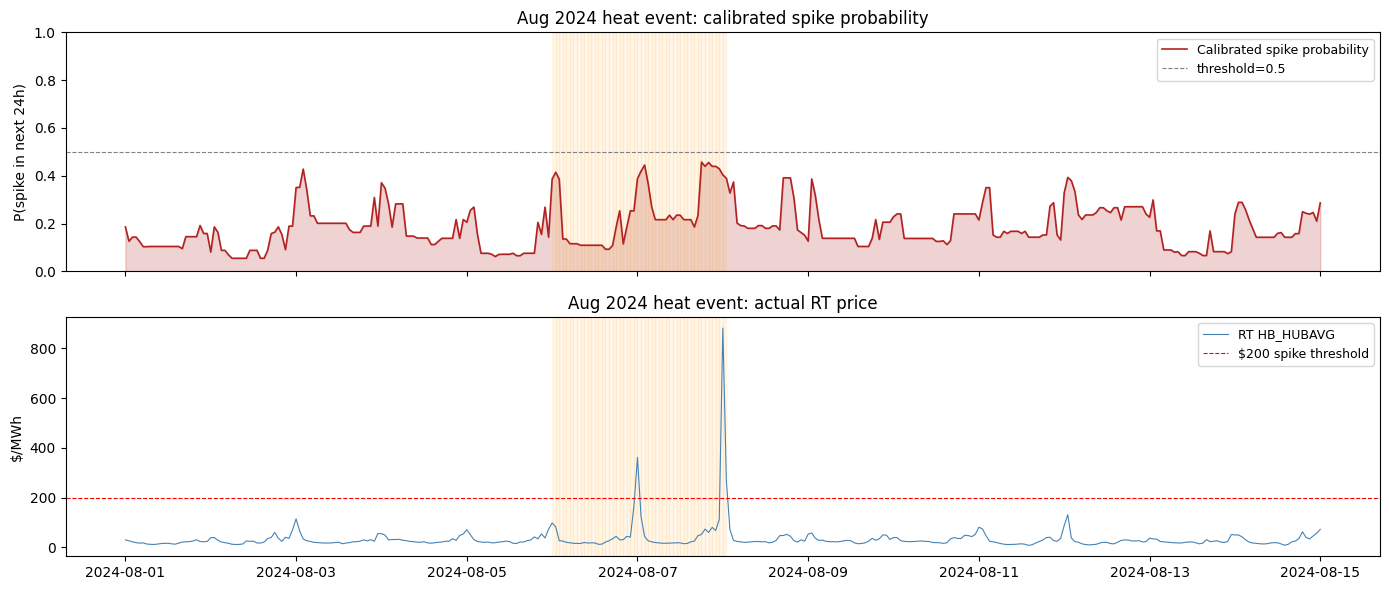

  Aug 2024 heat event: 337 hours,  spike hours flagged: 49
  Prob range: [0.055, 0.457]


In [8]:
# Cell 7 — Stress-event spotcheck
# Show calibrated spike probability vs actual RT price hour-by-hour
# for two 2024 events (out-of-sample): Jan 2024 cold snap and Aug 2024 heat.

best_cal = cal_isotonic if best_label == "isotonic" else cal_platt

def plot_stress_event(label, start, end):
    mask = (te_clf.index >= start) & (te_clf.index <= end)
    if mask.sum() == 0:
        print(f"  {label}: no test data in [{start}, {end}] — skipping")
        return
    event = te_clf.loc[mask]
    X_event = event[features].ffill().fillna(0)
    proba_event = best_cal.predict_proba(X_event)[:, 1]
    actual_price = mat.loc[event.index, TARGET_REG] if TARGET_REG in mat.columns else None

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    axes[0].plot(event.index, proba_event, lw=1.2, color="firebrick",
                 label="Calibrated spike probability")
    axes[0].axhline(0.5, color="gray", lw=0.8, linestyle="--", label="threshold=0.5")
    axes[0].fill_between(event.index, proba_event, alpha=0.2, color="firebrick")
    axes[0].set_ylabel("P(spike in next 24h)")
    axes[0].set_ylim(0, 1)
    axes[0].legend(fontsize=9)
    axes[0].set_title(f"{label}: calibrated spike probability")

    if actual_price is not None and not actual_price.empty:
        axes[1].plot(actual_price.index, actual_price.values,
                     lw=0.8, color="steelblue", label="RT HB_HUBAVG")
        axes[1].axhline(200, color="red", lw=0.8, linestyle="--", label="$200 spike threshold")
        axes[1].set_ylabel("$/MWh")
        axes[1].legend(fontsize=9)
        axes[1].set_title(f"{label}: actual RT price")

    # Overlay actual spike flags from test data
    spike_hours = event.index[event[TARGET_CLASS].fillna(0) == 1]
    for ax in axes:
        for sh in spike_hours:
            ax.axvspan(sh, sh + pd.Timedelta(hours=1),
                       alpha=0.08, color="orange")

    plt.tight_layout()
    plt.show()
    print(f"  {label}: {len(event)} hours,  spike hours flagged: {len(spike_hours)}")
    print(f"  Prob range: [{proba_event.min():.3f}, {proba_event.max():.3f}]")


# Jan 2024 cold snap
plot_stress_event(
    "Jan 2024 cold snap",
    "2024-01-13", "2024-01-20",
)

# Aug 2024 heat event
plot_stress_event(
    "Aug 2024 heat event",
    "2024-08-01", "2024-08-15",
)

In [9]:
from sklearn.metrics import average_precision_score
import numpy as np
_y_true_dollar = np.asarray(y_test_r).reshape(-1)
_y_pred_dollar = np.asarray(y_pred_test_r).reshape(-1)
_spike_pr_auc = average_precision_score(
    (_y_true_dollar > 200).astype(int),
    _y_pred_dollar,
)
print(f"\n=== Bake-off PR-AUC (regressor-as-score, threshold $200) ===")
print(f"  Spike PR-AUC: {_spike_pr_auc:.3f}")


=== Bake-off PR-AUC (regressor-as-score, threshold $200) ===
  Spike PR-AUC: 0.422


## Ablation — XGBoost without GDELT sentiment features
Identical to the enhanced run above (same `apply_feature_transforms`,
chronological split, hyperparameters, target), with the GDELT
sentiment columns removed and everything else kept (load, weather,
lags, gas, reactor, stress flags including `stress_score`). The
output below isolates the marginal contribution of GDELT sentiment.

In [10]:
# Strict GDELT-only ablation: keep every other column (including
# stress_score), remove only the sentiment columns.
features_no_gdelt = [f for f in features if not f.startswith("gdelt_")]
gdelt_dropped = sorted(set(features) - set(features_no_gdelt))
assert all(c.startswith("gdelt_") for c in gdelt_dropped), \
    "ablation must drop ONLY gdelt_* columns"
print(f"no-gdelt features: {len(features_no_gdelt)} (vs full: {len(features)})")
print(f"dropped (gdelt_* only): {gdelt_dropped}")

X_train_base = tr_reg[features_no_gdelt].ffill().fillna(0)
X_val_base   = vl_reg[features_no_gdelt].ffill().fillna(0)
X_test_base  = te_reg[features_no_gdelt].ffill().fillna(0)


no-gdelt features: 73 (vs full: 87)
dropped (gdelt_* only): ['gdelt_article_volume', 'gdelt_norm', 'gdelt_tone', 'gdelt_tone_change_1d', 'gdelt_tone_change_3d', 'gdelt_tone_lag_1d', 'gdelt_tone_lag_2d', 'gdelt_tone_lag_3d', 'gdelt_tone_zscore_30d', 'gdelt_volume_change_1d', 'gdelt_volume_change_3d', 'gdelt_volume_lag_1d', 'gdelt_volume_lag_2d', 'gdelt_volume_zscore_30d']


In [11]:
reg_base = xgb.XGBRegressor(
    n_estimators=700,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    early_stopping_rounds=30,
    eval_metric="rmse",
    n_jobs=-1,
    random_state=42,
)
reg_base.fit(X_train_base, y_train_r,
             eval_set=[(X_val_base, y_val_r)], verbose=False)
y_pred_test_base = reg_base.predict(X_test_base)
print("\nXGBoost (no GDELT) test metrics:")
reg_report_base = regression_report(
    y_test_r.values, y_pred_test_base,
    name="xgb_no_gdelt test",
)



XGBoost (no GDELT) test metrics:

--- Regression report: xgb_no_gdelt test ---
  MAE:             $24.64/MWh
  RMSE:            $114.20/MWh
  Spike recall:    57.89%
  Spike precision: 24.81%
---------------------------------



In [12]:
from sklearn.metrics import average_precision_score
import numpy as np
_y_true_dollar  = np.asarray(y_test_r).reshape(-1)
_y_pred_dollar  = np.asarray(y_pred_test_base).reshape(-1)
_spike_pr_auc_base = average_precision_score(
    (_y_true_dollar > 200).astype(int), _y_pred_dollar
)
print(f"\n=== Bake-off PR-AUC (no GDELT, regressor-as-score, $200) ===")
print(f"  Spike PR-AUC: {_spike_pr_auc_base:.3f}")

# reg_report wasn't captured for the enhanced run above;
# recompute from y_pred_test_r without modifying any existing cell.
reg_report = regression_report(
    y_test_r.values, y_pred_test_r,
    name="xgb_enhanced test",
)
print("\n=== With-GDELT vs No-GDELT summary ===")
print(f"  With GDELT (enhanced):  MAE ${reg_report['mae']:.2f}  "
      f"RMSE ${reg_report['rmse']:.2f}  "
      f"recall {reg_report['spike_recall']:.1%}  "
      f"prec {reg_report['spike_precision']:.1%}")
print(f"  Without GDELT:          MAE ${reg_report_base['mae']:.2f}  "
      f"RMSE ${reg_report_base['rmse']:.2f}  "
      f"recall {reg_report_base['spike_recall']:.1%}  "
      f"prec {reg_report_base['spike_precision']:.1%}")



=== Bake-off PR-AUC (no GDELT, regressor-as-score, $200) ===
  Spike PR-AUC: 0.400

--- Regression report: xgb_enhanced test ---
  MAE:             $22.21/MWh
  RMSE:            $108.88/MWh
  Spike recall:    54.39%
  Spike precision: 30.24%
---------------------------------


=== With-GDELT vs No-GDELT summary ===
  With GDELT (enhanced):  MAE $22.21  RMSE $108.88  recall 54.4%  prec 30.2%
  Without GDELT:          MAE $24.64  RMSE $114.20  recall 57.9%  prec 24.8%
